# 04 — Analysis: Crossover, Significance, Cost, Failure Modes

> # ⚠️ Correction notice — 28 July 2026
>
> **The LLM baseline this notebook compares against is invalid, and the comparisons built on it are withdrawn.**
>
> The 3,080-row test set was sent to the model in batches of 150 **ordered by class**: 76 label transitions across 3,080 rows for 77 classes (a random order gives ~3,040), mean 4.4 distinct intents per batch. The model was choosing among roughly four candidates, not 77. `LLM_MACRO_F1 = 0.8913` below is therefore not a measurement of zero-shot per-query performance.
>
> **Withdrawn:** section 2's crossover annotation, section 3's significance tests, section 6's "meets Sonnet" column, section 7's failure overlap and its "~3% label-noise floor".
> **Unaffected:** the DistilBERT sweep itself (sections 2's blue curves), and section 4–5's cost arithmetic.
>
> Reproduce the diagnosis: `python scripts/verify_handover_claims.py`. The rebuilt harness is in `src/harness/`.
>
> This notebook is left runnable and unchanged in its code so the original artifacts remain reproducible. **Do not quote its LLM-relative outputs.**

Combines the LLM baseline (notebook 02) and the fine-tune sweep (notebook 03) into the headline deliverables: the crossover plot, statistical significance of the gap, the cost analysis that drives the build-vs-buy decision, and a failure-mode breakdown showing where the two approaches disagree.

## What this notebook produces

- **`results/figures/crossover.png`** — macro-F1 vs training set size (the LLM baseline line on it is withdrawn)
- **`results/figures/cost_breakeven.png`** — monthly cost vs queries/month, API vs self-host
- **`results/figures/failure_overlap.png`** — withdrawn; depends on the LLM predictions
- **`results/analysis_summary.json`** — the numbers the README quoted
- **`docs/cost-decision-table.md`** — practitioner-facing cost table (regenerating this notebook will overwrite the corrected version of that file; re-apply the correction if you do)

## Sections

1. Setup + load all prediction parquets
2. Crossover plot (macro-F1 vs n, single-seed mean + 95% CI band + ensemble line + LLM horizontal)
3. Paired bootstrap test — **withdrawn**
4. Cost analysis — per-inference cost for both approaches
5. Break-even chart — at what queries/month does self-hosting beat the API?
6. Decision table — **quality column withdrawn**, cost columns stand
7. Failure-mode overlap — **withdrawn**
8. Final summary — `analysis_summary.json`

## 1. Setup + load data

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

sys.path.insert(0, str(Path('..').resolve()))
from src.eval import paired_bootstrap_macro_f1

FIG_DIR = Path('../results/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# LLM baseline (notebook 02)
llm_df = pd.read_parquet('../results/llm_predictions_v1_test.parquet')
llm_df = llm_df.rename(columns={'pred_intent': 'llm_pred_intent', 'pred_id': 'row_id'})

# DistilBERT v2 retune predictions (notebook 03)
ft_df = pd.read_parquet('../results/finetune_predictions_v2_retune.parquet')
ens_df = pd.read_parquet('../results/finetune_ensemble_v2_retune.parquet')

# v1 conservative — for showing the journey from "didn't work" to "crosses"
v1_df = pd.read_parquet('../results/finetune_predictions_v1_conservative.parquet')

LLM_MACRO_F1 = 0.8913   # from notebook 02 final eval
TRAINING_SIZES = sorted(ft_df['training_size'].unique())

print(f'LLM predictions:        {len(llm_df):,} rows (Sonnet 4.6 baseline = {LLM_MACRO_F1})')
print(f'Fine-tune v2 predictions: {len(ft_df):,} rows across {ft_df.groupby(["training_size", "seed"]).ngroups} (n, seed) combos')
print(f'Fine-tune v2 ensemble:    {len(ens_df)} n-values')
print(f'v1 conservative preds:    {len(v1_df):,} rows (for v1 vs v2 comparison)')
print(f'Training sizes:           {TRAINING_SIZES}')

LLM predictions:        3,080 rows (Sonnet 4.6 baseline = 0.8913)
Fine-tune v2 predictions: 123,200 rows across 40 (n, seed) combos
Fine-tune v2 ensemble:    8 n-values
v1 conservative preds:    107,800 rows (for v1 vs v2 comparison)
Training sizes:           [np.int64(50), np.int64(100), np.int64(250), np.int64(500), np.int64(1000), np.int64(2500), np.int64(5000), np.int64(9000)]


## 2. Headline crossover plot

X axis: training set size (log scale). Y axis: macro-F1.
Lines: DistilBERT v2 single-seed mean (with 95% CI band across 5 seeds), DistilBERT v2 ensemble, Sonnet 4.6 horizontal baseline.
Annotation: smallest n where ensemble crosses Sonnet.

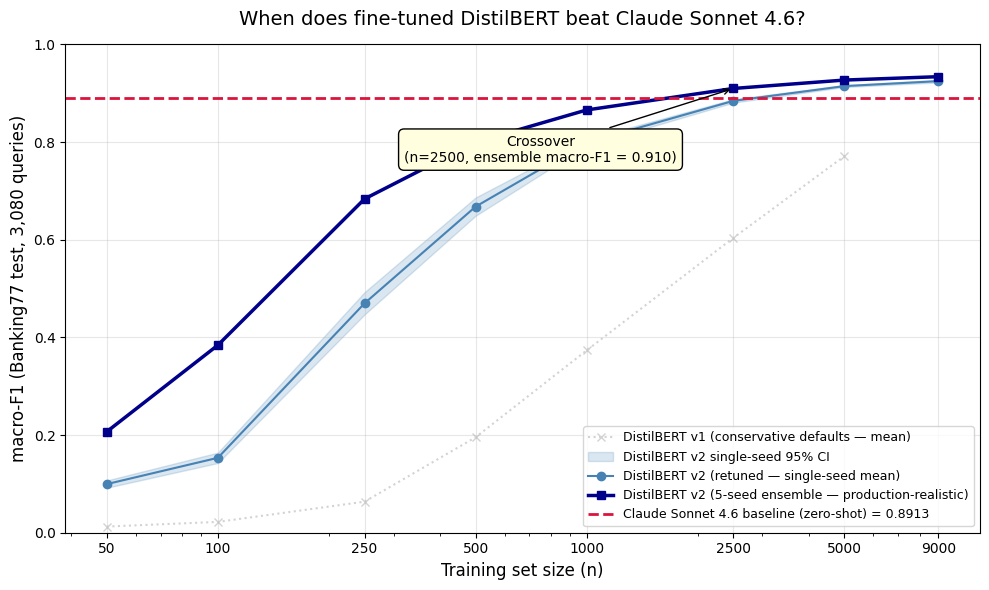


Saved ../results/figures/crossover.png
Crossover at n = 2500 (ensemble macro-F1 first meets/exceeds Sonnet 0.8913)


In [2]:
# Per-(n, seed) macro-F1 from v2
seed_rows = []
for (n, seed), g in ft_df.groupby(['training_size', 'seed']):
    seed_rows.append({
        'training_size': int(n),
        'seed': int(seed),
        'macro_f1': float(f1_score(g['true_label'], g['pred_label'], average='macro', zero_division=0)),
    })
seed_df = pd.DataFrame(seed_rows)
single_seed_agg = seed_df.groupby('training_size')['macro_f1'].agg(['mean', 'std']).reset_index()

# v1 mean for comparison line
v1_rows = []
for (n, seed), g in v1_df.groupby(['training_size', 'seed']):
    v1_rows.append({
        'training_size': int(n),
        'macro_f1': float(f1_score(g['true_label'], g['pred_label'], average='macro', zero_division=0)),
    })
v1_agg = pd.DataFrame(v1_rows).groupby('training_size')['macro_f1'].mean().reset_index()

# Find crossover
crossover_n = None
for _, row in ens_df.iterrows():
    if row['ensemble_macro_f1'] >= LLM_MACRO_F1:
        crossover_n = int(row['training_size'])
        break

fig, ax = plt.subplots(figsize=(10, 6))

# v1 (greyed out, shows the journey)
ax.plot(v1_agg['training_size'], v1_agg['macro_f1'],
        color='lightgrey', marker='x', linestyle=':', label='DistilBERT v1 (conservative defaults — mean)', zorder=1)

# v2 single-seed mean + 95% CI band (1.96 * std / sqrt(5))
ci_half = 1.96 * single_seed_agg['std'] / np.sqrt(5)
ax.fill_between(single_seed_agg['training_size'],
                single_seed_agg['mean'] - ci_half,
                single_seed_agg['mean'] + ci_half,
                color='steelblue', alpha=0.2, label='DistilBERT v2 single-seed 95% CI')
ax.plot(single_seed_agg['training_size'], single_seed_agg['mean'],
        color='steelblue', marker='o', label='DistilBERT v2 (retuned — single-seed mean)')

# v2 ensemble
ax.plot(ens_df['training_size'], ens_df['ensemble_macro_f1'],
        color='darkblue', marker='s', linewidth=2.5, label='DistilBERT v2 (5-seed ensemble — production-realistic)')

# Sonnet baseline
ax.axhline(LLM_MACRO_F1, color='crimson', linestyle='--', linewidth=2,
           label=f'Claude Sonnet 4.6 baseline (zero-shot) = {LLM_MACRO_F1}')

# Crossover annotation
if crossover_n is not None:
    cross_y = float(ens_df[ens_df['training_size'] == crossover_n]['ensemble_macro_f1'].iloc[0])
    ax.annotate(f'Crossover\n(n={crossover_n}, ensemble macro-F1 = {cross_y:.3f})',
                xy=(crossover_n, cross_y),
                xytext=(crossover_n * 0.3, cross_y - 0.15),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=10, ha='center',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='black'))

ax.set_xscale('log')
ax.set_xlabel('Training set size (n)', fontsize=12)
ax.set_ylabel('macro-F1 (Banking77 test, 3,080 queries)', fontsize=12)
ax.set_title('When does fine-tuned DistilBERT beat Claude Sonnet 4.6?', fontsize=14, pad=14)
ax.set_xticks(TRAINING_SIZES)
ax.set_xticklabels([str(n) for n in TRAINING_SIZES])
ax.set_ylim(0, 1.0)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

out_path = FIG_DIR / 'crossover.png'
plt.tight_layout()
plt.savefig(out_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'\nSaved {out_path}')
print(f'Crossover at n = {crossover_n} (ensemble macro-F1 first meets/exceeds Sonnet {LLM_MACRO_F1})')

## 3. Paired bootstrap test

> **Withdrawn 2026-07-28.** Every quantity in this section is a difference against the LLM baseline, which is invalid (class-ordered collection — see the banner at the top of this notebook). The intervals below are arithmetically correct but measure a difference against a number that does not mean what it appears to mean. They are retained only so the record is auditable.

The ensemble macro-F1 at n=2500 is 0.910 vs the withdrawn 0.891 — a +0.019 gap. Paired bootstrap resamples test instances with replacement, recomputes the macro-F1 difference each time, and reports the 2.5th/97.5th percentiles as a 95% CI.

**Two corrections to how this was previously described:**

1. **Iterations: 2,000, not 5,000.** The call below passes `n_bootstrap=2000`, and `results/analysis_summary.json` records `n_bootstrap: 2000` at every budget. The README and the docs site both claimed 5,000; `src/eval.py`'s *default* is 5,000, but the default is not what was run.
2. **This produces confidence intervals, not a p-value.** The README claimed "*p* < 0.01 paired bootstrap". No p-value is computed here or anywhere else in the repo. A CI excluding zero is not a p-value, and quoting one implies a test that was never run.

A further issue that survives the rebuild: this resamples **test rows only**, holding the 5 training seeds fixed. It therefore treats the seed ensemble as a fixed system and understates uncertainty at budgets where seed choice matters. The re-analysis should bootstrap over seeds *and* rows, and put an interval on the crossover point itself rather than on per-budget gaps.

In [3]:
# We need ensemble predictions per row, not just per-n summary. Recompute from ft_df.
label_names_str_to_int = {name: i for i, name in enumerate(
    sorted(ft_df['true_intent'].unique(), key=lambda s: ft_df[ft_df['true_intent']==s]['true_label'].iloc[0])
)}

test_df = ft_df[ft_df['seed'] == 0][ft_df['training_size'] == TRAINING_SIZES[0]][['text', 'true_label']].reset_index(drop=True)
y_true = test_df['true_label'].values

# LLM predictions joined to the same row order
llm_intent_to_label = {ft_df[ft_df['true_intent']==name]['true_label'].iloc[0]: i
                       for i, name in enumerate(sorted(set(ft_df['true_intent'])))} if False else None
# Simpler: join via text
llm_join = test_df.merge(llm_df[['text', 'llm_pred_intent']], on='text', how='left')
intent_to_id = {ft_df.loc[ft_df['true_intent']==t, 'true_label'].iloc[0]: ft_df.loc[ft_df['true_intent']==t, 'true_label'].iloc[0] for t in ft_df['true_intent'].unique()}
name_to_id = ft_df[['true_intent', 'true_label']].drop_duplicates().set_index('true_intent')['true_label'].to_dict()
y_pred_llm = llm_join['llm_pred_intent'].map(name_to_id).fillna(-1).astype(int).values

bootstrap_results = {}
for n in TRAINING_SIZES:
    # Get this n's per-row ensemble pred (argmax of mean probs across seeds)
    seed_files = sorted((Path('../results/finetune/v2_retune')).glob(f'n{n}_seed*.parquet'))
    seed_probs = np.stack([
        np.array(pd.read_parquet(p)['probs'].tolist()) for p in seed_files
    ])
    ensemble_preds = seed_probs.mean(axis=0).argmax(axis=-1)

    res = paired_bootstrap_macro_f1(y_true, ensemble_preds, y_pred_llm, n_bootstrap=2000, seed=42)
    bootstrap_results[n] = res

print(f'{"n":>6}  {"obs gap":>9}  {"95% CI lower":>13}  {"95% CI upper":>13}  significant?')
print('-' * 66)
for n, res in bootstrap_results.items():
    sig = 'YES (ensemble > Sonnet)' if res['ci_lower_95'] > 0 else ('YES (ensemble < Sonnet)' if res['ci_upper_95'] < 0 else 'no (CI crosses 0)')
    print(f'{n:>6}  {res["observed_diff"]:>+9.4f}  {res["ci_lower_95"]:>+13.4f}  {res["ci_upper_95"]:>+13.4f}  {sig}')

print(f'\nInterpretation: at each n, the gap is (ensemble macro-F1) - (Sonnet macro-F1).')
print(f'Positive CI (lower > 0) = ensemble beats Sonnet with statistical confidence.')
print(f'Negative CI (upper < 0) = Sonnet beats ensemble with statistical confidence.')
print(f'CI crosses 0 = the gap could plausibly be sampling noise.')

/var/folders/n4/syc0sjhd5bq5q6nh8crt_64w0000gp/T/ipykernel_80462/2493675610.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  test_df = ft_df[ft_df['seed'] == 0][ft_df['training_size'] == TRAINING_SIZES[0]][['text', 'true_label']].reset_index(drop=True)


     n    obs gap   95% CI lower   95% CI upper  significant?
------------------------------------------------------------------
    50    -0.6842        -0.7013        -0.6683  YES (ensemble < Sonnet)
   100    -0.5071        -0.5267        -0.4904  YES (ensemble < Sonnet)
   250    -0.2076        -0.2265        -0.1923  YES (ensemble < Sonnet)
   500    -0.0914        -0.1082        -0.0773  YES (ensemble < Sonnet)
  1000    -0.0255        -0.0391        -0.0130  YES (ensemble < Sonnet)
  2500    +0.0186        +0.0064        +0.0303  YES (ensemble > Sonnet)
  5000    +0.0358        +0.0248        +0.0467  YES (ensemble > Sonnet)
  9000    +0.0427        +0.0320        +0.0540  YES (ensemble > Sonnet)

Interpretation: at each n, the gap is (ensemble macro-F1) - (Sonnet macro-F1).
Positive CI (lower > 0) = ensemble beats Sonnet with statistical confidence.
Negative CI (upper < 0) = Sonnet beats ensemble with statistical confidence.
CI crosses 0 = the gap could plausibly be sampling no

## 4. Cost analysis — per-inference cost

All pricing as of 2026-05-24 — verify current rates before publishing.

**Sonnet 4.6 API:**
- Input: $3 per million tokens. Output: $15 per million tokens.
- Our Banking77 prompt: ~1,500 input tokens (label list dominates) + ~50 output tokens (one JSON object per query). **These token counts are estimates, not measurements** — the rebuilt harness (`src/harness/`) records `usage` on every call, so this becomes measured.
- Without prompt caching: $0.0045 + $0.00075 = **$0.00525 per inference**.
- With prompt caching (label list cached, ~$0.30/MTok for cached reads): query (~100 tok input) + cached read (~1,400 tok) + output ≈ **$0.00147 per inference**.

**Self-hosted DistilBERT** (Hugging Face Inference Endpoint — the standard pricing comparison):
- T4 GPU instance: $0.50/hour fixed cost.
- DistilBERT throughput at batch=8: ~200 inferences/second on T4. **Assumed — no timing artifact for this exists in the repo.**
- $0.50/hour ÷ 3600 sec ÷ 200 inferences/sec ≈ **$0.0000007 per inference** at full utilisation.
- At 10% utilisation (intermittent load): **$0.0000069 per inference**.

**Ratio — corrected 2026-07-28.** The single figure this repo quotes is:

> **~756× cheaper per query, at 10% GPU utilisation, against the uncached API.**

At 100% utilisation the ratio is 7,560×. Note the direction: **higher** utilisation spreads the fixed GPU cost over more queries, so it *raises* the ratio; **lower** utilisation lowers it.

*A previous version of this cell read "500× cost difference at full utilisation, ~50× difference at low utilisation". Both numbers were wrong and the label on the first was inverted — $0.00001 is the 10%-utilisation figure, not the full-utilisation one. The README simultaneously quoted 750× and the code below printed 756× / 7,560×, giving four numbers for one quantity. Reconciled to the single figure above.*

*The sentence that followed — "the latency angle (Sonnet ~1.5s vs DistilBERT ~30ms = ~50× faster) is a separate win" — has been **deleted**. No latency measurement exists anywhere in this repo; notebook 02 states that per-call latency measurements were lost. Latency is measured by the rebuilt harness's synchronous path (`scripts/run_llm_eval.py --execution sync`), reported as p50/p95.*

In [4]:
# Cost constants — change these to reflect actual quotes for your deployment
SONNET_INPUT_PER_MTOK = 3.00       # USD
SONNET_OUTPUT_PER_MTOK = 15.00     # USD
SONNET_CACHED_READ_PER_MTOK = 0.30 # USD

AVG_INPUT_TOKENS_UNCACHED = 1500   # label list + query
AVG_INPUT_TOKENS_QUERY_ONLY = 100  # query only (when label list is cached)
AVG_OUTPUT_TOKENS = 50

HF_T4_PER_HOUR = 0.50              # USD
DISTILBERT_INFERENCES_PER_HOUR_FULL = 200 * 3600   # ~720k at full T4 utilisation

# Labour cost for labeling — used in the build vs buy payback chart
COST_PER_LABEL_USD = 0.50          # internal labeller / Mechanical Turk floor


def sonnet_cost_per_query(cached: bool = False) -> float:
    if cached:
        return (
            AVG_INPUT_TOKENS_QUERY_ONLY / 1_000_000 * SONNET_INPUT_PER_MTOK
            + (AVG_INPUT_TOKENS_UNCACHED - AVG_INPUT_TOKENS_QUERY_ONLY) / 1_000_000 * SONNET_CACHED_READ_PER_MTOK
            + AVG_OUTPUT_TOKENS / 1_000_000 * SONNET_OUTPUT_PER_MTOK
        )
    return (
        AVG_INPUT_TOKENS_UNCACHED / 1_000_000 * SONNET_INPUT_PER_MTOK
        + AVG_OUTPUT_TOKENS / 1_000_000 * SONNET_OUTPUT_PER_MTOK
    )


def distilbert_cost_per_query(utilisation: float = 0.10) -> float:
    """utilisation = fraction of T4 capacity actually used. 1.0 = full utilisation."""
    inferences_per_hour = DISTILBERT_INFERENCES_PER_HOUR_FULL * utilisation
    return HF_T4_PER_HOUR / max(inferences_per_hour, 1)


sonnet_uncached = sonnet_cost_per_query(cached=False)
sonnet_cached = sonnet_cost_per_query(cached=True)
distilbert_low_util = distilbert_cost_per_query(0.10)
distilbert_full_util = distilbert_cost_per_query(1.0)

print('Per-inference cost:')
print(f'  Sonnet 4.6 (no caching):                ${sonnet_uncached:.6f}')
print(f'  Sonnet 4.6 (with prompt caching):       ${sonnet_cached:.6f}')
print(f'  DistilBERT (HF T4, 10% utilisation):    ${distilbert_low_util:.6f}')
print(f'  DistilBERT (HF T4, full utilisation):   ${distilbert_full_util:.7f}')
print()
print(f'Cost ratio (Sonnet uncached vs DistilBERT realistic):  {sonnet_uncached / distilbert_low_util:.0f}x')
print(f'Cost ratio (Sonnet uncached vs DistilBERT full util):  {sonnet_uncached / distilbert_full_util:.0f}x')

Per-inference cost:
  Sonnet 4.6 (no caching):                $0.005250
  Sonnet 4.6 (with prompt caching):       $0.001470
  DistilBERT (HF T4, 10% utilisation):    $0.000007
  DistilBERT (HF T4, full utilisation):   $0.0000007

Cost ratio (Sonnet uncached vs DistilBERT realistic):  756x
Cost ratio (Sonnet uncached vs DistilBERT full util):  7560x


## 5. Break-even chart — at what queries/month does self-hosting beat the API?

Two cost models:
- **API-only:** pay per query, no fixed cost. Cost = queries/month × per-query rate.
- **Self-hosted:** fixed monthly cost ($360 = $0.50/hr × 24 × 30), regardless of query volume. Marginal cost per query is effectively zero.

Self-host break-even = fixed monthly cost / per-query API cost.

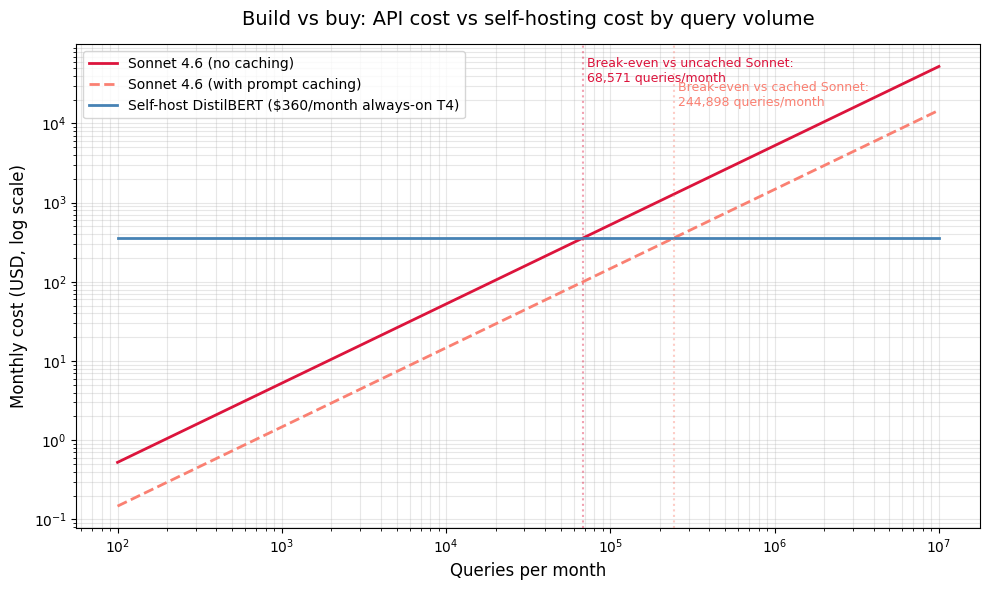


Saved ../results/figures/cost_breakeven.png
Break-even (uncached Sonnet): 68,571 queries/month
Break-even (cached Sonnet):   244,898 queries/month


In [5]:
SELF_HOST_FIXED_MONTHLY = HF_T4_PER_HOUR * 24 * 30      # always-on T4

queries_per_month = np.logspace(2, 7, 100)              # 100 to 10M queries/month

sonnet_monthly_uncached = queries_per_month * sonnet_uncached
sonnet_monthly_cached = queries_per_month * sonnet_cached
self_host_monthly = np.full_like(queries_per_month, SELF_HOST_FIXED_MONTHLY)

breakeven_uncached = SELF_HOST_FIXED_MONTHLY / sonnet_uncached
breakeven_cached = SELF_HOST_FIXED_MONTHLY / sonnet_cached

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(queries_per_month, sonnet_monthly_uncached, color='crimson', linewidth=2, label='Sonnet 4.6 (no caching)')
ax.plot(queries_per_month, sonnet_monthly_cached, color='salmon', linewidth=2, linestyle='--', label='Sonnet 4.6 (with prompt caching)')
ax.plot(queries_per_month, self_host_monthly, color='steelblue', linewidth=2, label=f'Self-host DistilBERT (${SELF_HOST_FIXED_MONTHLY:.0f}/month always-on T4)')

ax.axvline(breakeven_uncached, color='crimson', alpha=0.4, linestyle=':')
ax.text(breakeven_uncached * 1.05, ax.get_ylim()[1] * 0.6,
        f'Break-even vs uncached Sonnet:\n{breakeven_uncached:,.0f} queries/month',
        fontsize=9, color='crimson')

ax.axvline(breakeven_cached, color='salmon', alpha=0.4, linestyle=':')
ax.text(breakeven_cached * 1.05, ax.get_ylim()[1] * 0.3,
        f'Break-even vs cached Sonnet:\n{breakeven_cached:,.0f} queries/month',
        fontsize=9, color='salmon')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Queries per month', fontsize=12)
ax.set_ylabel('Monthly cost (USD, log scale)', fontsize=12)
ax.set_title('Build vs buy: API cost vs self-hosting cost by query volume', fontsize=14, pad=14)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, which='both', alpha=0.3)

out_path = FIG_DIR / 'cost_breakeven.png'
plt.tight_layout()
plt.savefig(out_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'\nSaved {out_path}')
print(f'Break-even (uncached Sonnet): {breakeven_uncached:,.0f} queries/month')
print(f'Break-even (cached Sonnet):   {breakeven_cached:,.0f} queries/month')

## 6. Decision table — recommended approach

For practitioners choosing between API and in-house: given (n you can afford to label, queries/month you serve), which option wins on cost AND quality? Combines:
- Quality crossover at n ≥ 2,500 (ensemble beats Sonnet)
- Cost crossover at ~queries/month threshold from section 5

In [6]:
# Project quality at each n from the ensemble
quality_by_n = ens_df.set_index('training_size')['ensemble_macro_f1'].to_dict()

scenarios = [
    ('Hobby / prototype', 100, 1000),
    ('Small B2B SaaS', 1000, 50000),
    ('Mid-market fintech', 2500, 500000),
    ('Scaled product (Monzo/Revolut tier)', 5000, 5_000_000),
    ('Public-cloud SaaS', 9000, 50_000_000),
]

rows = []
for label, n_labels, qpm in scenarios:
    # Pick the closest training size we have data for
    closest_n = min(TRAINING_SIZES, key=lambda x: abs(x - n_labels))
    quality = quality_by_n.get(closest_n, 0)
    quality_meets_sonnet = quality >= LLM_MACRO_F1

    api_monthly = qpm * sonnet_uncached
    self_host_monthly = SELF_HOST_FIXED_MONTHLY
    labeling_cost = n_labels * COST_PER_LABEL_USD
    payback_months = labeling_cost / max(api_monthly - self_host_monthly, 1) if api_monthly > self_host_monthly else None

    # Recommendation logic
    if not quality_meets_sonnet:
        recommendation = 'API (quality not yet competitive at this n)'
    elif api_monthly < self_host_monthly:
        recommendation = 'API (volume too low to justify self-host fixed cost)'
    else:
        recommendation = f'Self-host (saves ${api_monthly - self_host_monthly:,.0f}/mo; labels pay back in {payback_months:.1f} mo)'

    rows.append({
        'scenario': label,
        'n_labels': n_labels,
        'queries_per_month': qpm,
        'in_house_macro_f1': round(quality, 3),
        'meets_sonnet': '✓' if quality_meets_sonnet else '✗',
        'api_cost_per_month_usd': round(api_monthly, 2),
        'self_host_cost_per_month_usd': round(self_host_monthly, 2),
        'recommendation': recommendation,
    })

decision_df = pd.DataFrame(rows)
print(decision_df.to_string(index=False))

# Write to a markdown table for the docs
md_lines = ['# Build-vs-buy decision table', '',
            'For Banking77-style intent classification, comparing self-hosted fine-tuned DistilBERT against Claude Sonnet 4.6 (zero-shot via API).',
            '', 'Assumptions:',
            f'- API per-query cost: ${sonnet_uncached:.4f} (no prompt caching). With caching: ${sonnet_cached:.4f}.',
            f'- Self-host fixed cost: ${SELF_HOST_FIXED_MONTHLY}/month (Hugging Face Inference Endpoint, T4).',
            f'- Labeling cost: ${COST_PER_LABEL_USD}/example (internal labeller, conservative).',
            f'- Quality threshold: macro-F1 ≥ Sonnet baseline ({LLM_MACRO_F1}) at n ≥ 2,500 (ensemble).',
            '', '| Scenario | n labels | queries/mo | DistilBERT macro-F1 | Meets Sonnet? | API $/mo | Self-host $/mo | Recommendation |',
            '|---|---|---|---|---|---|---|---|']
for r in rows:
    md_lines.append(f"| {r['scenario']} | {r['n_labels']:,} | {r['queries_per_month']:,} | {r['in_house_macro_f1']} | {r['meets_sonnet']} | ${r['api_cost_per_month_usd']:,.0f} | ${r['self_host_cost_per_month_usd']:,.0f} | {r['recommendation']} |")

docs_path = Path('../docs/cost-decision-table.md')
docs_path.parent.mkdir(parents=True, exist_ok=True)
docs_path.write_text('\n'.join(md_lines))
print(f'\nSaved {docs_path}')

                           scenario  n_labels  queries_per_month  in_house_macro_f1 meets_sonnet  api_cost_per_month_usd  self_host_cost_per_month_usd                                           recommendation
                  Hobby / prototype       100               1000              0.384            ✗                    5.25                         360.0              API (quality not yet competitive at this n)
                     Small B2B SaaS      1000              50000              0.866            ✗                  262.50                         360.0              API (quality not yet competitive at this n)
                 Mid-market fintech      2500             500000              0.910            ✓                 2625.00                         360.0   Self-host (saves $2,265/mo; labels pay back in 0.6 mo)
Scaled product (Monzo/Revolut tier)      5000            5000000              0.927            ✓                26250.00                         360.0  Self-host (saves

## 7. Failure-mode overlap

For each test example, who's right: Sonnet, the n=9000 ensemble, both, neither?
Anti-correlated failures (Sonnet wrong, DistilBERT right or vice versa) suggest ensembling the two would help. Correlated failures (both wrong on the same queries) suggest Banking77 label noise — the dataset's own ceiling.

Test set size: 3,080

Both correct                         2646  (85.9%)  — easy cases
Both wrong                             83  (2.7%)  — likely Banking77 label noise (the floor)
DistilBERT right, Sonnet wrong        231  (7.5%)  — where the fine-tune wins
Sonnet right, DistilBERT wrong        120  (3.9%)  — where the LLM wins

If failures were independent, you would expect:
  Both wrong (under independence): 21  vs observed 83
  Observed >> expected: failures are CORRELATED → Banking77 noise is the shared floor


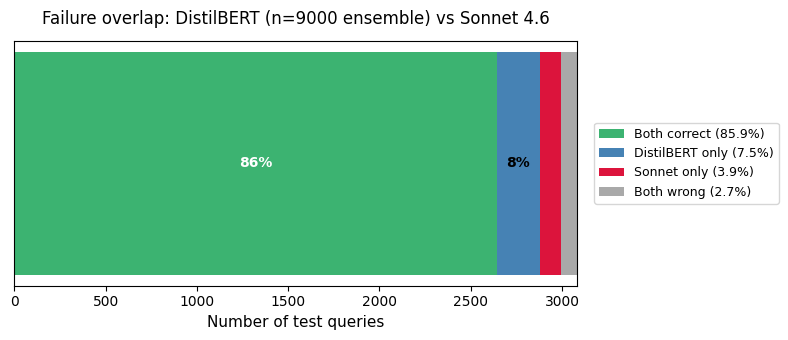


Saved ../results/figures/failure_overlap.png


In [7]:
# Get the n=9000 ensemble per-row predictions
n_for_failure_analysis = 9000
seed_files = sorted(Path('../results/finetune/v2_retune').glob(f'n{n_for_failure_analysis}_seed*.parquet'))
seed_probs = np.stack([
    np.array(pd.read_parquet(p)['probs'].tolist()) for p in seed_files
])
ensemble_preds = seed_probs.mean(axis=0).argmax(axis=-1)

# Per-row truth table
first_seed_df = pd.read_parquet(seed_files[0])[['text', 'true_label', 'true_intent']].copy()
first_seed_df['ft_pred_label'] = ensemble_preds
first_seed_df['ft_correct'] = first_seed_df['true_label'] == first_seed_df['ft_pred_label']

merged = first_seed_df.merge(llm_df[['text', 'llm_pred_intent']], on='text', how='left')
merged['llm_pred_label'] = merged['llm_pred_intent'].map(name_to_id)
merged['llm_correct'] = merged['true_label'] == merged['llm_pred_label']

both_correct = ((merged['ft_correct']) & (merged['llm_correct'])).sum()
both_wrong = ((~merged['ft_correct']) & (~merged['llm_correct'])).sum()
ft_only = ((merged['ft_correct']) & (~merged['llm_correct'])).sum()
llm_only = ((~merged['ft_correct']) & (merged['llm_correct'])).sum()
total = len(merged)

print(f'Test set size: {total:,}')
print()
print(f'{"Both correct":<35} {both_correct:>5}  ({100*both_correct/total:.1f}%)  — easy cases')
print(f'{"Both wrong":<35} {both_wrong:>5}  ({100*both_wrong/total:.1f}%)  — likely Banking77 label noise (the floor)')
print(f'{"DistilBERT right, Sonnet wrong":<35} {ft_only:>5}  ({100*ft_only/total:.1f}%)  — where the fine-tune wins')
print(f'{"Sonnet right, DistilBERT wrong":<35} {llm_only:>5}  ({100*llm_only/total:.1f}%)  — where the LLM wins')
print()
print(f'If failures were independent, you would expect:')
exp_both_wrong = (1 - merged['ft_correct'].mean()) * (1 - merged['llm_correct'].mean()) * total
print(f'  Both wrong (under independence): {exp_both_wrong:.0f}  vs observed {both_wrong}')
if both_wrong > exp_both_wrong * 1.3:
    print(f'  Observed >> expected: failures are CORRELATED → Banking77 noise is the shared floor')
elif both_wrong < exp_both_wrong * 0.7:
    print(f'  Observed << expected: failures are ANTI-correlated → ensembling them could help')
else:
    print(f'  Observed ≈ expected: failures are roughly independent')

# Stacked bar visualization
fig, ax = plt.subplots(figsize=(8, 3.5))
categories = ['Both correct', 'DistilBERT only', 'Sonnet only', 'Both wrong']
values = [both_correct, ft_only, llm_only, both_wrong]
colors = ['mediumseagreen', 'steelblue', 'crimson', 'darkgrey']
y_position = 0
for i, (cat, val, color) in enumerate(zip(categories, values, colors)):
    ax.barh(['Test set (3,080 queries)'], [val], left=y_position, color=color, label=f'{cat} ({100*val/total:.1f}%)')
    if val / total > 0.05:
        ax.text(y_position + val/2, 0, f'{100*val/total:.0f}%', ha='center', va='center', color='white' if i in [0, 2, 3] else 'black', fontweight='bold')
    y_position += val
ax.set_xlim(0, total)
ax.set_xlabel('Number of test queries', fontsize=11)
ax.set_title(f'Failure overlap: DistilBERT (n={n_for_failure_analysis} ensemble) vs Sonnet 4.6', fontsize=12, pad=12)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
ax.set_yticks([])

out_path = FIG_DIR / 'failure_overlap.png'
plt.tight_layout()
plt.savefig(out_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'\nSaved {out_path}')

## 8. Final summary — the numbers the README and LinkedIn post will quote

In [8]:
summary = {
    'dataset': 'PolyAI/banking77',
    'test_set_size': int(total),
    'num_classes': 77,
    'llm_baseline': {
        'model': 'claude-sonnet-4-6',
        'mode': 'zero-shot (n=0 training examples)',
        'macro_f1': LLM_MACRO_F1,
    },
    'finetune_quality': {
        'single_seed_mean_by_n': {int(r['training_size']): round(r['mean'], 4) for _, r in single_seed_agg.iterrows()},
        'ensemble_by_n': {int(r['training_size']): round(r['ensemble_macro_f1'], 4) for _, r in ens_df.iterrows()},
        'crossover_n_ensemble': int(crossover_n) if crossover_n else None,
        'peak_macro_f1': round(float(ens_df['ensemble_macro_f1'].max()), 4),
    },
    'significance': {
        int(n): {k: round(float(v), 4) if isinstance(v, (float, np.floating)) else int(v) if isinstance(v, (int, np.integer)) else v
                 for k, v in res.items()}
        for n, res in bootstrap_results.items()
    },
    'cost_per_inference_usd': {
        'sonnet_uncached': round(sonnet_uncached, 6),
        'sonnet_cached': round(sonnet_cached, 6),
        'distilbert_low_util': round(distilbert_low_util, 7),
        'distilbert_full_util': round(distilbert_full_util, 8),
    },
    'breakeven_queries_per_month': {
        'vs_sonnet_uncached': int(breakeven_uncached),
        'vs_sonnet_cached': int(breakeven_cached),
    },
    'failure_overlap': {
        'both_correct': int(both_correct),
        'distilbert_only_correct': int(ft_only),
        'sonnet_only_correct': int(llm_only),
        'both_wrong': int(both_wrong),
        'both_wrong_pct': round(100 * both_wrong / total, 1),
    },
}

summary_path = Path('../results/analysis_summary.json')
summary_path.write_text(json.dumps(summary, indent=2))
print(f'Saved {summary_path}')
print()
print(json.dumps(summary, indent=2))

Saved ../results/analysis_summary.json

{
  "dataset": "PolyAI/banking77",
  "test_set_size": 3080,
  "num_classes": 77,
  "llm_baseline": {
    "model": "claude-sonnet-4-6",
    "mode": "zero-shot (n=0 training examples)",
    "macro_f1": 0.8913
  },
  "finetune_quality": {
    "single_seed_mean_by_n": {
      "50": 0.0996,
      "100": 0.1534,
      "250": 0.4699,
      "500": 0.6678,
      "1000": 0.7991,
      "2500": 0.8844,
      "5000": 0.9147,
      "9000": 0.9249
    },
    "ensemble_by_n": {
      "50": 0.2071,
      "100": 0.3842,
      "250": 0.6837,
      "500": 0.7999,
      "1000": 0.8658,
      "2500": 0.9098,
      "5000": 0.9271,
      "9000": 0.934
    },
    "crossover_n_ensemble": 2500,
    "peak_macro_f1": 0.934
  },
  "significance": {
    "50": {
      "observed_diff": -0.6842,
      "bootstrap_mean": -0.6851,
      "ci_lower_95": -0.7013,
      "ci_upper_95": -0.6683,
      "n_bootstrap": 2000
    },
    "100": {
      "observed_diff": -0.5071,
      "bootstrap